# Personal Information
Name: **Amelia Soare**

StudentID: **15343480**

Email: [**ameliasoare@student.uva.nl**](ameliasoare@student.uva.nl)

Submitted on: **DD.MM.YYYY**

# Data Context

> **Data Use Agreement Compliance Statement**  
> Throughout this analysis, all use of MIMIC-III data has been conducted in full compliance with the PhysioNet Credentialed Health Data Use Agreement 1.5.0. Raw patient-level data, identifiers, and any information that could permit re-identification of individuals have not been disclosed, shared, or misused for the purpose of this thesis. This notebook is prepared exclusively for lawful scientific research. No raw MIMIC-III records are reproduced here; all outputs are aggregate statistics, distributions, or derived features from the pre-processed benchmark pipeline [2].

For each patient, multivariate time series will be constructed over a predefined observation window after ICU admission and preprocessed following the mimic3-benchmarks pipeline which provides standardized definitions for four clinical prediction targets: 
- in-hospital mortality (IHM)
- decompensation
- length-of-stay (LOS)
- phenotyping 

To enable model development and fair assessment, data will be divided into training, validation, and test sets following the benchmark split conventions, where the test set will be held globally and will not be accessed during model selection or training.

To coordinate a realistic VFL scenario, we partition the features between $K=3$ clients, where each client $k$ has a disjoint subset of $d_k$ features such that $\sum_{k=1}^{K} d_k = d$. Each client is assigned a distinct prediction task. Although the mimic3-benchmarks pipeline defines four tasks, decompensation is excluded from the client assignment because it requires a dense rolling 24-hour window incompatible with the stay-level aggregation used here; it is retained as a potential auxiliary signal in future work. The three-client vertical split is as follows:

| Client | Features ($d_k$) | Assigned Task |
|--------|-----------------|---------------|
| Site A | 7 vital signs | In-hospital mortality (binary, 48 h window) |
| Site B | 4 lab values | Length-of-stay (10-class ordinal) |
| Site C | 3 composite measurements | Phenotyping (multi-label, ICD-9 CCS groups) |

To coordinate training across sites, we identify patients that appear in all three sites. Each site converts its patient IDs into anonymised codes (hashes) before sharing. This method allows the sites to find their shared patients without exposing their full patient lists. Only patients present at all three sites are used for joint training.

---

**References**  
[1] A. E. W. Johnson et al., "MIMIC-III, a freely accessible critical care database," *Scientific Data*, vol. 3, p. 160035, 2016. https://physionet.org/content/mimiciii/1.4/  
[2] H. Harutyunyan et al., "Multitask learning and benchmarking with clinical time series data," *Scientific Data*, vol. 6, p. 96, 2019. https://doi.org/10.1038/s41597-019-0103-9

# Data Description


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Global plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

### Data Loading

In [2]:
# Paths to vertical split outputs — adjust DATA_DIR if running from a different working directory
DATA_DIR = 'data/vertical_splits'

site_a  = pd.read_csv(os.path.join(DATA_DIR, 'site_A_vitals.csv'))
site_b  = pd.read_csv(os.path.join(DATA_DIR, 'site_B_labs.csv'))
site_c  = pd.read_csv(os.path.join(DATA_DIR, 'site_C_composite.csv'))
aligned = pd.read_csv(os.path.join(DATA_DIR, 'aligned_patient_ids.csv'))

# Check columns per site
print("Site A columns:", site_a.columns.tolist())
print(f"  -> {site_a.shape[0]:,} stays × {site_a.shape[1]} columns")
print()
print("Site B columns:", site_b.columns.tolist())
print(f"  -> {site_b.shape[0]:,} stays × {site_b.shape[1]} columns")
print()
print("Site C columns:", site_c.columns.tolist())
print(f"  -> {site_c.shape[0]:,} stays × {site_c.shape[1]} columns")
print()
print("Aligned columns:", aligned.columns.tolist())
print(f"  -> {aligned.shape[0]:,} patients × {aligned.shape[1]} columns")

Site A columns: ['stay', 'subject_id', 'Heart Rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Temperature', 'Oxygen saturation', 'Respiratory rate', 'Glascow coma scale total', 'y_ihm', 'split']
  -> 21,139 stays × 11 columns

Site B columns: ['stay', 'subject_id', 'Glucose', 'pH', 'Fraction inspired oxygen', 'Capillary refill rate', 'y_los', 'split']
  -> 41,788 stays × 8 columns

Site C columns: ['stay', 'subject_id', 'Height', 'Weight', 'Mean blood pressure', 'Acute and unspecified renal failure', 'Acute cerebrovascular disease', 'Acute myocardial infarction', 'Cardiac dysrhythmias', 'Chronic kidney disease', 'Chronic obstructive pulmonary disease and bronchiectasis', 'Complications of surgical procedures or medical care', 'Conduction disorders', 'Congestive heart failure; nonhypertensive', 'Coronary atherosclerosis and other heart disease', 'Diabetes mellitus with complications', 'Diabetes mellitus without complication', 'Disorders of lipid metabolism', 'Essential hy

In [3]:
# Define feature columns per site (matching the vertical split protocol)
FEATURES_A = ['Heart Rate', 'Systolic blood pressure', 'Diastolic blood pressure',
               'Temperature', 'Oxygen saturation', 'Respiratory rate',
               'Glascow coma scale total']
FEATURES_B = ['Glucose', 'pH', 'Fraction inspired oxygen', 'Capillary refill rate']
FEATURES_C = ['Height', 'Weight', 'Mean blood pressure']

# Site C carries all columns that are not identifiers, features, or split markers.
# Everything left over must be a phenotype label — these are the ICD-9 CCS groups
# assigned by the YerevaNN mimic3-benchmarks phenotyping pipeline.
NON_LABEL_COLS_C = ['stay', 'subject_id'] + FEATURES_C + ['split']
PHENO_COLS = [c for c in site_c.columns if c not in NON_LABEL_COLS_C]

print(f'Non-label columns in Site C : {NON_LABEL_COLS_C}')
print(f'Phenotype label columns: {len(PHENO_COLS)}')
print()
for i, col in enumerate(PHENO_COLS, 1):
    print(f'  {i:2d}. {col}')

Non-label columns in Site C : ['stay', 'subject_id', 'Height', 'Weight', 'Mean blood pressure', 'split']
Phenotype label columns: 25

   1. Acute and unspecified renal failure
   2. Acute cerebrovascular disease
   3. Acute myocardial infarction
   4. Cardiac dysrhythmias
   5. Chronic kidney disease
   6. Chronic obstructive pulmonary disease and bronchiectasis
   7. Complications of surgical procedures or medical care
   8. Conduction disorders
   9. Congestive heart failure; nonhypertensive
  10. Coronary atherosclerosis and other heart disease
  11. Diabetes mellitus with complications
  12. Diabetes mellitus without complication
  13. Disorders of lipid metabolism
  14. Essential hypertension
  15. Fluid and electrolyte disorders
  16. Gastrointestinal hemorrhage
  17. Hypertension with complications and secondary hypertension
  18. Other liver diseases
  19. Other lower respiratory disease
  20. Other upper respiratory disease
  21. Pleurisy; pneumothorax; pulmonary collapse
  22

### Analysis 1: Dataset Overview and Feature Statistics

Each site covers a different number of ICU stays because eligibility criteria differ per task. The table below shows stay counts and train/val/test proportions per site and for the aligned cohort.

Descriptive statistics (mean, std, quartiles) are also reported per site. 

Handling missing values: All features have been forward-filled → backward-filled → mean-imputed during the vertical split step. Values represent **stay-level aggregated means** (one row per ICU stay).

In [4]:
# --- Dataset size and split overview ---
def split_counts(df, label):
    vc = df['split'].value_counts().reindex(['train', 'val', 'test'], fill_value=0)
    total = vc.sum()
    return pd.Series({
        'Dataset':       label,
        'Total stays':   f'{total:,}',
        'Train':         f"{vc['train']:,} ({100*vc['train']/total:.1f}%)",
        'Val':           f"{vc['val']:,}   ({100*vc['val']/total:.1f}%)",
        'Test':          f"{vc['test']:,}  ({100*vc['test']/total:.1f}%)",
    })

overview = pd.DataFrame([
    split_counts(site_a,  'Site A — IHM       (7 vitals)'),
    split_counts(site_b,  'Site B — LOS       (4 labs)'),
    split_counts(site_c,  'Site C — Phenotyping (3 composite)'),
    split_counts(aligned, 'PSI-aligned cohort (all sites)'),
]).set_index('Dataset')
display(overview)

# --- Feature descriptive statistics per site ---
def describe_site(df, feature_cols, site_label):
    desc = df[feature_cols].describe().T
    desc.columns = ['N', 'Mean', 'Std', 'Min', 'Q25', 'Median', 'Q75', 'Max']
    desc = desc.drop(columns='N').round(3)
    print(f'\n{site_label}')
    display(desc)

,Total stays,Train,Val,Test
Dataset,,,,
Site A — IHM (7 vitals),"21,139","14,681 (69.4%)","3,222 (15.2%)","3,236 (15.3%)"
Site B — LOS (4 labs),"41,788","29,168 (69.8%)","6,355 (15.2%)","6,265 (15.0%)"
Site C — Phenotyping (3 composite),"41,902","29,250 (69.8%)","6,371 (15.2%)","6,281 (15.0%)"
PSI-aligned cohort (all sites),"18,094","12,149 (67.1%)","2,839 (15.7%)","3,106 (17.2%)"


In [5]:
# --- Feature descriptive statistics per site ---
def describe_site(df, feature_cols, site_label):
    desc = df[feature_cols].describe().T
    desc.columns = ['N', 'Mean', 'Std', 'Min', 'Q25', 'Median', 'Q75', 'Max']
    desc = desc.drop(columns='N').round(3)
    print(f'\n{site_label}')
    display(desc)

describe_site(site_a, FEATURES_A, 'Site A — Vitals (7 features)')
# • Heart Rate and SBP medians (86, 118) are clinically normal for ICU patients
# • GCS total range 3–15 matches the valid scale — no out-of-range values
# • DBP, SpO2, RespRate, and Temp all have implausibly large max values
#   (Temp max = 285°C, SpO2 max = 29,818%) — these may be data entry errors
# • The large gap between std and IQR for these features confirms the errors are
#   isolated spikes rather than general spread; winsorisation (handling extreme outliers by capping values at a chosen percentile) is needed before training


Site A — Vitals (7 features)


,Mean,Std,Min,Q25,Median,Q75,Max
Heart Rate,86.779,14.730,35.537,76.461,86.154,96.481,154.383
Systolic blood pressure,120.317,16.289,27.889,108.371,118.084,130.492,191.625
Diastolic blood pressure,60.893,10.237,13.889,53.917,59.944,66.869,111.905
Temperature,36.888,0.566,31.600,36.530,36.882,37.235,40.100
Oxygen saturation,96.738,2.503,18.000,95.750,97.060,98.243,100.000
Respiratory rate,19.150,3.891,6.932,16.452,18.660,21.307,42.762
Glascow coma scale total,11.583,2.492,3.000,11.244,11.583,13.024,15.000


In [6]:
describe_site(site_b, FEATURES_B, 'Site B — Labs (4 features)')
# • Glucose and pH have extreme max values (15,356 and 99) far beyond any plausible range — data entry errors
# • FiO2 and Capillary Refill Rate show identical Q25 = median = Q75, meaning the vast majority of values
#   are the same number — a sign of heavy mean imputation where most patients had no recorded measurement
# • Features with flat quartiles are statistically near-constant and may carry little signal for the model


Site B — Labs (4 features)


,Mean,Std,Min,Q25,Median,Q75,Max
Glucose,137.277,40.996,33.00,112.707,129.087,150.777,788.219
pH,7.195,0.308,6.30,7.194,7.230,7.381,8.400
Fraction inspired oxygen,0.539,0.078,0.21,0.539,0.539,0.539,1.000
Capillary refill rate,0.170,0.040,0.00,0.170,0.170,0.170,1.000


In [7]:
describe_site(site_c, FEATURES_C, 'Site C — Composite (3 features)')
# • Height: Q25 = median = Q75 = 168.6 — nearly all values are identical, indicating heavy mean imputation
# • Weight max = 3,761,721 and std = 18,377 — one or a few extreme artefacts dominate the variance entirely
# • Mean BP is the most statistically normal of the three: std (17.7) is close to the IQR, suggesting
#   a reasonably spread distribution with only moderate outlier influence
# • Min = 0 for all three features — patients with no recorded measurement were imputed, but zeros
#   slipped through for some stays; these should be treated as missing before training


Site C — Composite (3 features)


,Mean,Std,Min,Q25,Median,Q75,Max
Height,168.537,6.888,0.0,168.503,168.503,168.503,240.00
Weight,82.183,20.570,0.0,70.412,82.187,88.517,250.00
Mean blood pressure,79.163,10.753,14.0,71.831,78.237,85.503,140.75


### Analysis 2: Label Distributions

Each site is assigned a distinct prediction task; understanding label distributions is essential for selecting loss functions and interpreting evaluation metrics.

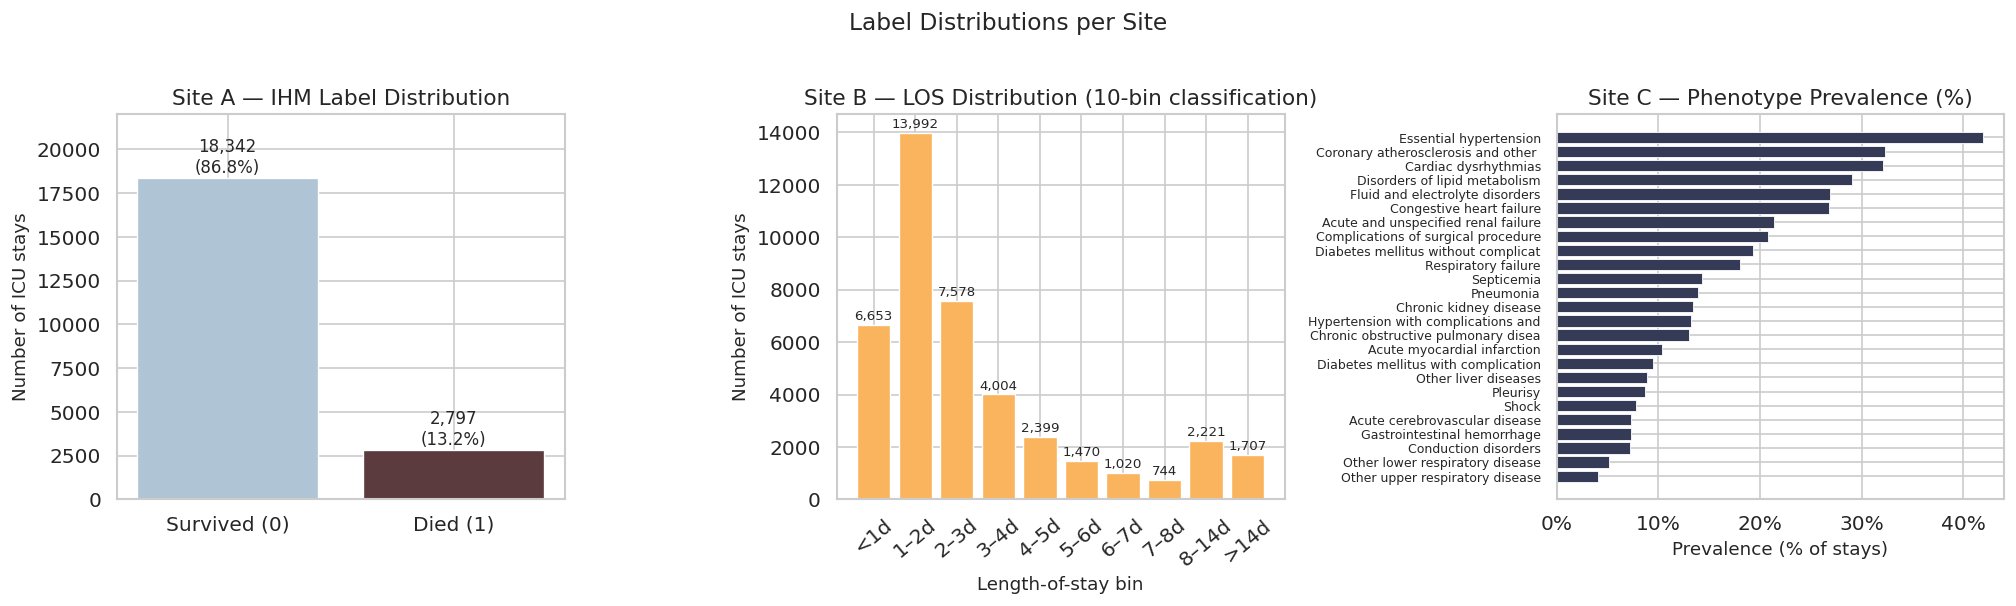

In [8]:
PALETTE = ["#fbb45e", "#5b3b3e", "#ad8d86", "#c99379", "#afc4d5", "#7d7585", "#353b56"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Site A: IHM binary class balance ---
ax = axes[0]
vc = site_a['y_ihm'].value_counts().sort_index()
bars = ax.bar(['Survived (0)', 'Died (1)'], vc.values,
               color=[PALETTE[4], PALETTE[1]], edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 120,
            f'{v:,}\n({100*v/vc.sum():.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Site A — IHM Label Distribution')
ax.set_ylabel('Number of ICU stays')
ax.set_ylim(0, vc.max() * 1.2)

# --- Site B: LOS binned into 10 CustomBins classes ---
ax = axes[1]
los_boundaries = [0, 24, 48, 72, 96, 120, 144, 168, 192, 336, np.inf]
bin_labels = ['<1d', '1–2d', '2–3d', '3–4d', '4–5d',
              '5–6d', '6–7d', '7–8d', '8–14d', '>14d']
los_binned = pd.cut(site_b['y_los'], bins=los_boundaries, labels=bin_labels, right=False)
los_counts = los_binned.value_counts().reindex(bin_labels, fill_value=0)
bars = ax.bar(bin_labels, los_counts.values,
              color=PALETTE[0], edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, los_counts.values):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                f'{v:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Site B — LOS Distribution (10-bin classification)')
ax.set_xlabel('Length-of-stay bin')
ax.set_ylabel('Number of ICU stays')
ax.tick_params(axis='x', rotation=40)

# --- Site C: Phenotype prevalence (sorted) ---
ax = axes[2]
pheno_prev = site_c[PHENO_COLS].mean().sort_values(ascending=True) * 100
short_names = [n.split('(')[0].split(';')[0].strip()[:35] for n in pheno_prev.index]
ax.barh(short_names, pheno_prev.values,
        color=PALETTE[6], edgecolor='white', linewidth=0.5)
ax.set_title('Site C — Phenotype Prevalence (%)')
ax.set_xlabel('Prevalence (% of stays)')
ax.tick_params(axis='y', labelsize=7.5)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Label Distributions per Site', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

- **Site A — IHM**: Binary outcome. The ~13% positive rate reflects real ICU mortality and creates class imbalance. AUC-ROC is used as the primary metric to handle this.
- **Site B — LOS**: Continuous outcome (hours) binned into 10 ordinal classes using the YerevaNN CustomBins scheme (boundaries: 1, 2, 3, 4, 5, 6, 7, 8, 14 days). The distribution is right-skewed: the shortest bins (`<1d`, `1–2d`+) dominate and longer stays become progressively rarer. Treated as 10-class classification with Cohen's κ as the primary metric.
- **Site C — Phenotyping**: Multi-label outcome with 25 ICD-9 code groups. Each label is independently binary. Prevalences span from under ~4% to over 40%, creating severe label imbalance across conditions.Macro-AUC is used to give equal weight to rare and common phenotypes. 

### Analysis 3: Feature Distributions, Inter-Feature Correlation, and Phenotype Co-occurrence

**Cross-site feature correlations** (Circos chord diagram): absolute Pearson correlations on PSI-aligned patients; within-site pairs are zeroed out so all chords cross site boundaries. SBP–MeanBP is an example cross-site pair visible here.

**3a: Feature distributions** (box plots, Z-score scaled within each site) reveal the spread and outlier profile of each variable. Whiskers extend to 1.5× IQR; outliers are retained — they represent clinically plausible extremes already validated by the YerevaNN pipeline.

**3b: Correlation matrices** (Pearson) show within-site linear relationships. Expected physiological pairs such as SBP–DBP confirm the split is internally coherent.

**3c: Phenotype co-occurrence** quantifies how often two ICD-9 labels are simultaneously positive in the same stay.

Merged aligned cohort: 18,094 patients with all 14 features
Non-zero cross-site feature pairs: 61


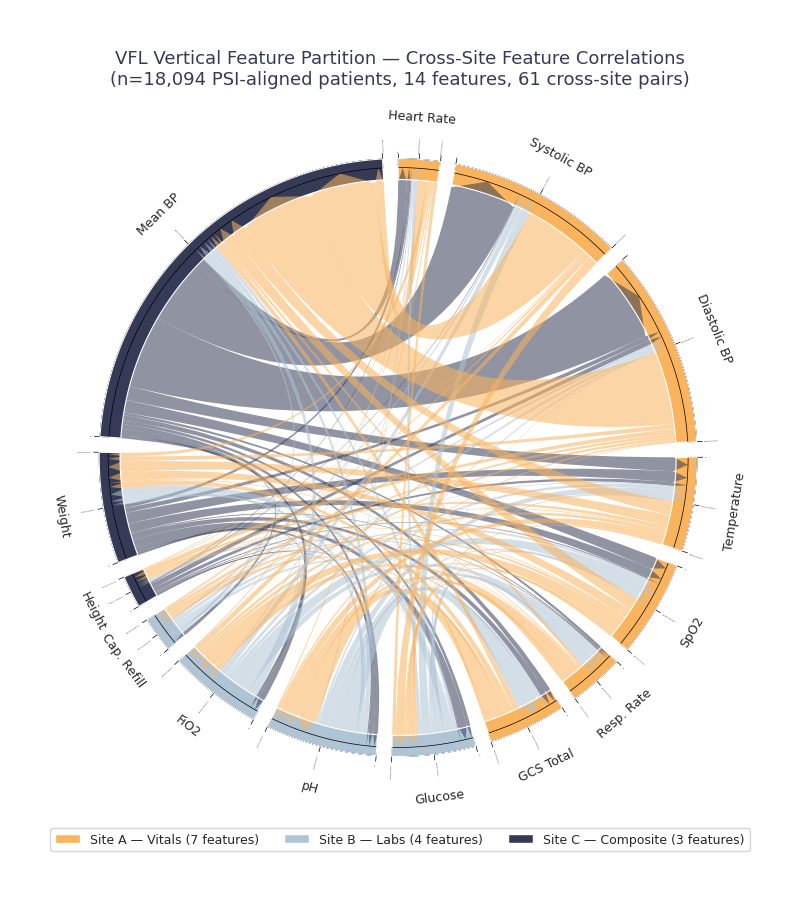

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycirclize import Circos

PALETTE = ["#fbb45e", "#5b3b3e", "#ad8d86", "#c99379", "#afc4d5", "#7d7585", "#353b56"]

FEAT_MAP = {'Site A': FEATURES_A, 'Site B': FEATURES_B, 'Site C': FEATURES_C}

DISPLAY_NAMES = {
    'Heart Rate': 'Heart Rate',
    'Systolic blood pressure': 'Systolic BP',
    'Diastolic blood pressure': 'Diastolic BP',
    'Temperature': 'Temperature',
    'Oxygen saturation': 'SpO2',
    'Respiratory rate': 'Resp. Rate',
    'Glascow coma scale total': 'GCS Total',
    'Glucose': 'Glucose',
    'pH': 'pH',
    'Fraction inspired oxygen': 'FiO2',
    'Capillary refill rate': 'Cap. Refill',
    'Height': 'Height',
    'Weight': 'Weight',
    'Mean blood pressure': 'Mean BP',
}

# ── Cross-site Pearson correlations on PSI-aligned patients ───────────────
aligned_subs = set(aligned['subject_id'])

def first_stay(df, feats):
    return (df[df['subject_id'].isin(aligned_subs)]
            .sort_values('stay')
            .groupby('subject_id')[feats]
            .first())

merged = (first_stay(site_a, FEATURES_A)
          .join(first_stay(site_b, FEATURES_B), how='inner')
          .join(first_stay(site_c, FEATURES_C), how='inner'))

print(f"Merged aligned cohort: {len(merged):,} patients with all 14 features")

# 14×14 absolute correlation matrix, display names as index/columns
all_feats = FEATURES_A + FEATURES_B + FEATURES_C
corr_full = merged[all_feats].corr().abs().copy()
corr_full.index   = [DISPLAY_NAMES[f] for f in all_feats]
corr_full.columns = [DISPLAY_NAMES[f] for f in all_feats]

# Zero-out within-site pairs and the diagonal — chords only cross sites
for feats in [FEATURES_A, FEATURES_B, FEATURES_C]:
    disp = [DISPLAY_NAMES[f] for f in feats]
    corr_full.loc[disp, disp] = 0.0
for name in corr_full.index:
    corr_full.loc[name, name] = 0.0

n_links = int((corr_full > 0).sum().sum() // 2)
print(f"Non-zero cross-site feature pairs: {n_links}")

# ── Color map ───────────────────────
sector_colors = (
    {DISPLAY_NAMES[f]: PALETTE[0] for f in FEATURES_A} |  
    {DISPLAY_NAMES[f]: PALETTE[4] for f in FEATURES_B} | 
    {DISPLAY_NAMES[f]: PALETTE[6] for f in FEATURES_C}    
)

# ── Circos ────────────────────────────────
circos = Circos.initialize_from_matrix(
    corr_full,
    space=3,
    cmap=sector_colors,
    label_kws=dict(size=9, r=112),
    link_kws=dict(ec="none", lw=0.1, alpha=0.55, direction=1),
)

for sector in circos.sectors:
    color = sector_colors.get(sector.name, PALETTE[5])

    # Colored outer band 
    outer = sector.add_track((93, 100))
    outer.axis(fc=color, ec="white", lw=0.8)

    # Tick lines without numeric labels
    outer.xticks_by_interval(
        interval=max(sector.size / 2, 0.01),
        label_size=0,
        label_orientation="vertical",
        show_bottom_line=True,
    )

fig = circos.plotfig(figsize=(8, 8))
fig.patch.set_facecolor("white")

ax = fig.axes[0]
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0 - 0.05, pos.width, pos.height])

# Site legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=PALETTE[0], edgecolor="white", label=f"Site A — Vitals ({len(FEATURES_A)} features)"),
    Patch(facecolor=PALETTE[4], edgecolor="white", label=f"Site B — Labs ({len(FEATURES_B)} features)"),
    Patch(facecolor=PALETTE[6], edgecolor="white", label=f"Site C — Composite ({len(FEATURES_C)} features)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    "VFL Vertical Feature Partition — Cross-Site Feature Correlations\n"
    f"(n={len(merged):,} PSI-aligned patients, 14 features, {n_links} cross-site pairs)",
    fontsize=13, y=1.02, color="#353b56",
)

plt.show()


/scratch-local/asoare.21082309/ipykernel_3645711/2735276343.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scaled.melt(var_name='Feature', value_name='Z-score'),
/scratch-local/asoare.21082309/ipykernel_3645711/2735276343.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scaled.melt(var_name='Feature', value_name='Z-score'),
/scratch-local/asoare.21082309/ipykernel_3645711/2735276343.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scaled.melt(var_name='Feature', value_name='Z-score'),


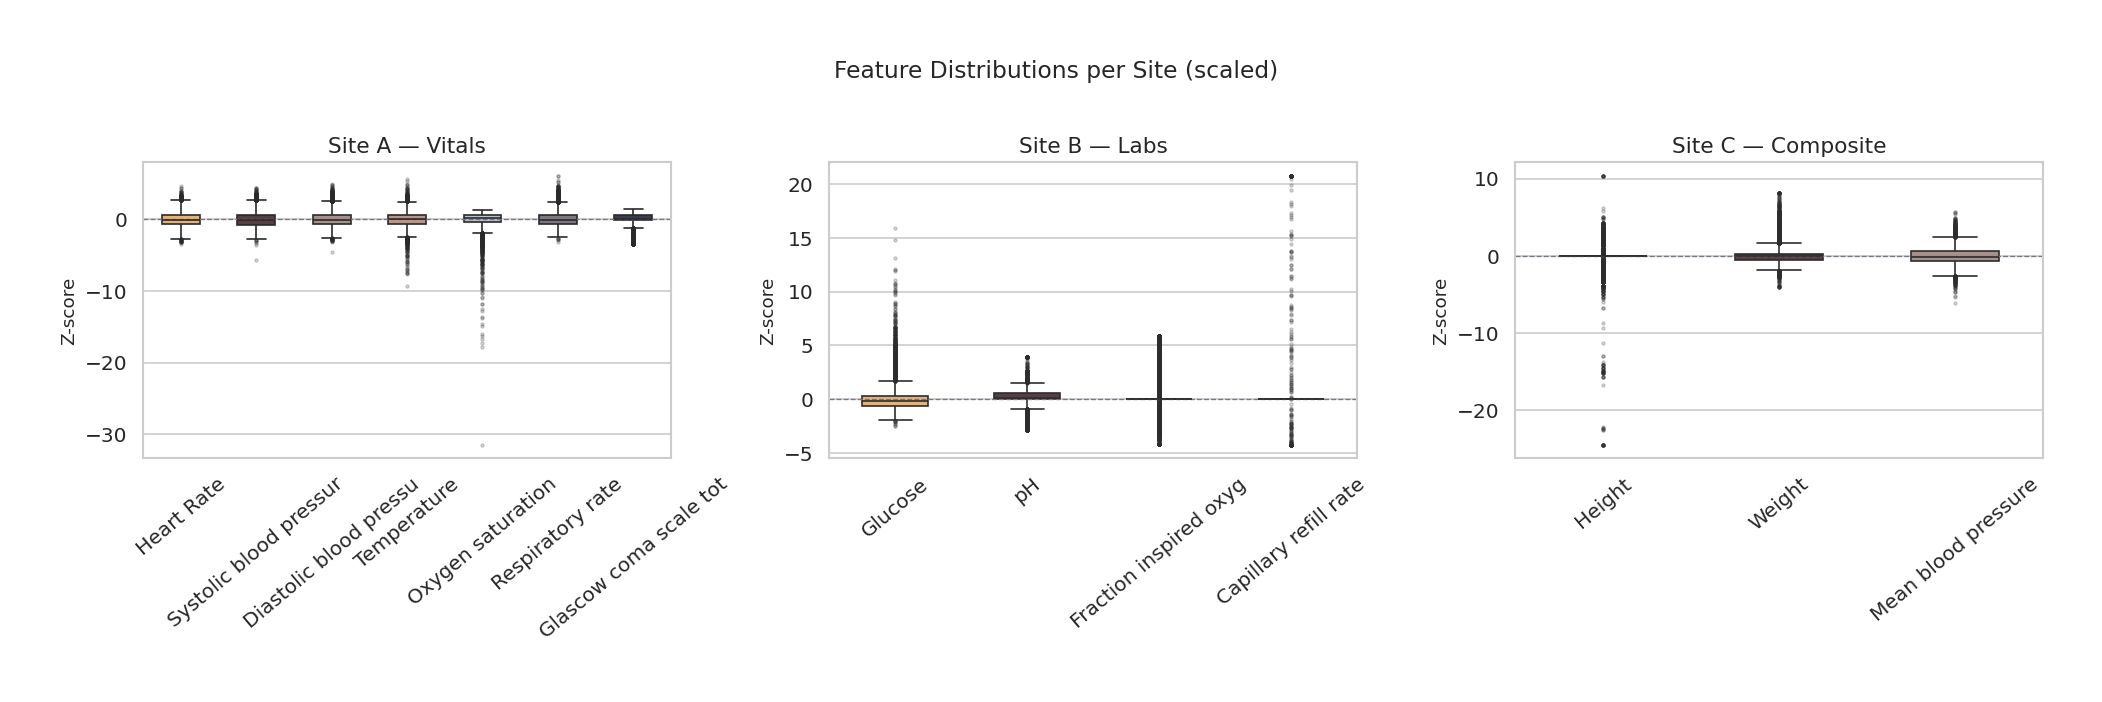

In [10]:
from matplotlib.colors import LinearSegmentedColormap

PALETTE = ["#fbb45e", "#5b3b3e", "#ad8d86", "#c99379", "#afc4d5", "#7d7585", "#353b56"]

# ── 3a: Feature distributions (Z-score scaled box plots) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, cols, title) in zip(axes, [
    (site_a, FEATURES_A, 'Site A — Vitals'),
    (site_b, FEATURES_B, 'Site B — Labs'),
    (site_c, FEATURES_C, 'Site C — Composite'),
]):
    scaled = (df[cols] - df[cols].mean()) / df[cols].std()
    scaled.columns = [c[:22] for c in scaled.columns]
    box_palette = PALETTE[:len(cols)]   
    sns.boxplot(data=scaled.melt(var_name='Feature', value_name='Z-score'),
                x='Feature', y='Z-score', palette=box_palette, width=0.5,
                fliersize=1.5, flierprops=dict(alpha=0.3), ax=ax)
    ax.axhline(0, color=PALETTE[5], linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('Feature Distributions per Site (scaled)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

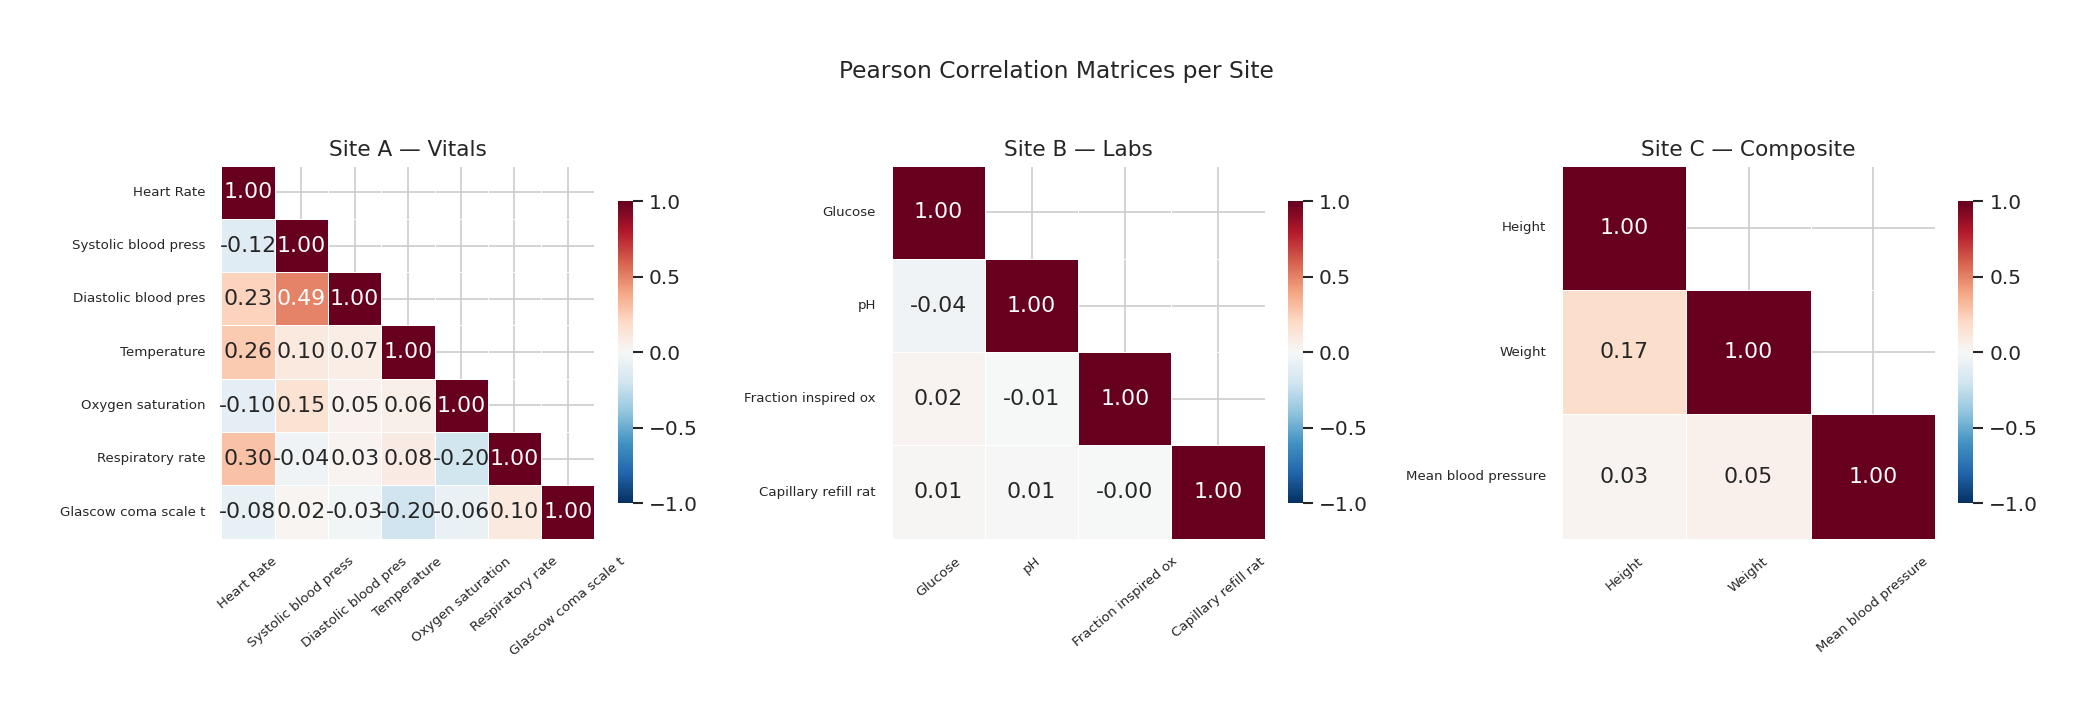

In [11]:
# ── 3b: Pearson correlation matrices ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, cols, title) in zip(axes, [
    (site_a, FEATURES_A, 'Site A — Vitals'),
    (site_b, FEATURES_B, 'Site B — Labs'),
    (site_c, FEATURES_C, 'Site C — Composite'),
]):
    corr = df[cols].corr()
    corr.index = corr.columns = [c[:20] for c in cols]
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.7}, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Pearson Correlation Matrices per Site', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

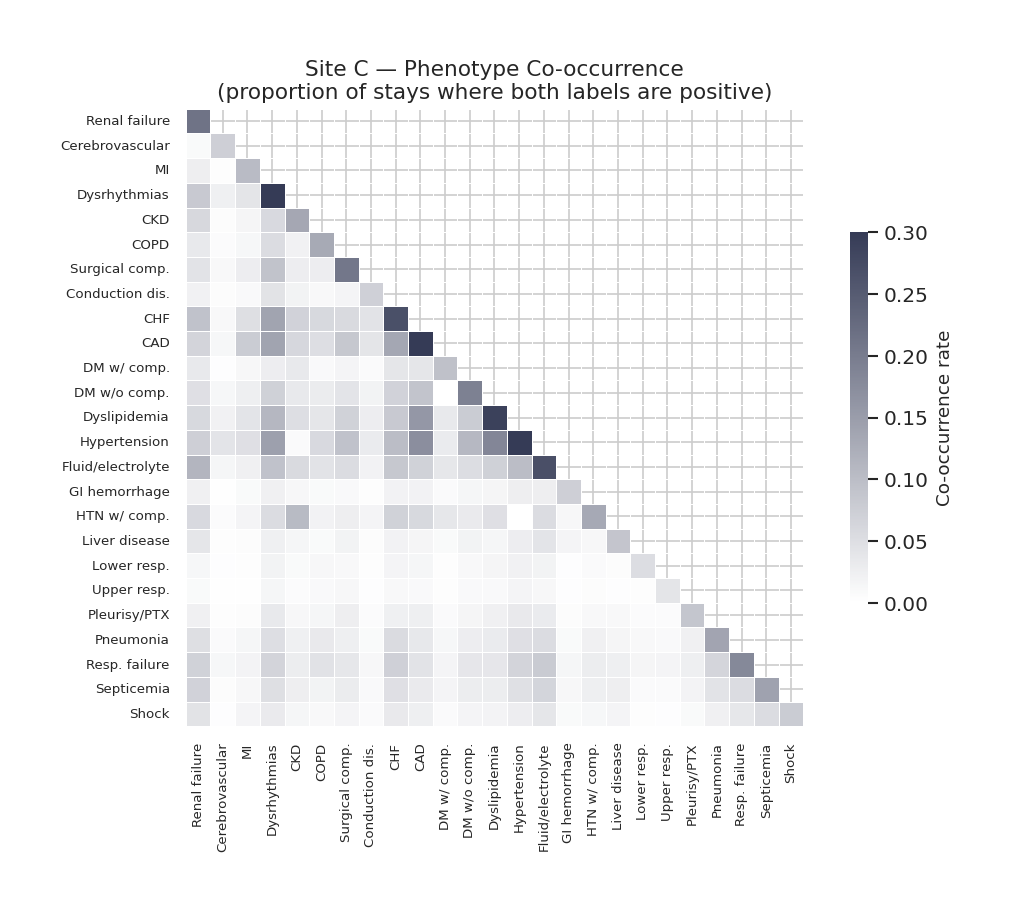

In [12]:
# ── 3c: Phenotype co-occurrence heatmap (Site C) ──────────────────────────
abbrev = {
    'Acute and unspecified renal failure':                                        'Renal failure',
    'Acute cerebrovascular disease':                                              'Cerebrovascular',
    'Acute myocardial infarction':                                                'MI',
    'Cardiac dysrhythmias':                                                       'Dysrhythmias',
    'Chronic kidney disease':                                                     'CKD',
    'Chronic obstructive pulmonary disease and bronchiectasis':                   'COPD',
    'Complications of surgical procedures or medical care':                       'Surgical comp.',
    'Conduction disorders':                                                       'Conduction dis.',
    'Congestive heart failure; nonhypertensive':                                  'CHF',
    'Coronary atherosclerosis and other heart disease':                           'CAD',
    'Diabetes mellitus with complications':                                       'DM w/ comp.',
    'Diabetes mellitus without complication':                                     'DM w/o comp.',
    'Disorders of lipid metabolism':                                              'Dyslipidemia',
    'Essential hypertension':                                                     'Hypertension',
    'Fluid and electrolyte disorders':                                            'Fluid/electrolyte',
    'Gastrointestinal hemorrhage':                                                'GI hemorrhage',
    'Hypertension with complications and secondary hypertension':                 'HTN w/ comp.',
    'Other liver diseases':                                                       'Liver disease',
    'Other lower respiratory disease':                                            'Lower resp.',
    'Other upper respiratory disease':                                            'Upper resp.',
    'Pleurisy; pneumothorax; pulmonary collapse':                                 'Pleurisy/PTX',
    'Pneumonia (except that caused by tuberculosis or sexually transmitted disease)': 'Pneumonia',
    'Respiratory failure; insufficiency; arrest (adult)':                         'Resp. failure',
    'Septicemia (except in labor)':                                               'Septicemia',
    'Shock':                                                                      'Shock',
}
pheno_data = site_c[PHENO_COLS].rename(columns=abbrev)
cooccur = pheno_data.T.dot(pheno_data) / len(pheno_data)

navy_cmap = LinearSegmentedColormap.from_list('navy', ['#ffffff', PALETTE[6]])

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(cooccur, dtype=bool), k=1)
sns.heatmap(cooccur, mask=mask, cmap=navy_cmap, vmin=0, vmax=0.3,
            linewidths=0.3, square=True,
            cbar_kws={'label': 'Co-occurrence rate', 'shrink': 0.6},
            ax=ax)
ax.set_title('Site C — Phenotype Co-occurrence\n'
             '(proportion of stays where both labels are positive)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

### Analysis 4: Temporal Coverage and Per-feature Observation Rate

The model input is a tensor of shape `(48, n_features)` — one row per hour of the ICU stay. In this section we explore how full is the 48-hour window and which features are actually recorded and when.

Both plots are computed on a random sample of 300 training stays per site from the raw (pre-imputation) timeseries files.

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BENCH_ROOT = 'data/mimic3-benchmarks/data'
MAX_SEQ    = 48
N_SAMPLE   = 300
_rng       = np.random.RandomState(42)

SITE_CFGS = {
    'Site A\n(7 vitals)': {
        'df':       site_a,
        'features': FEATURES_A,
        'ts_root':  os.path.join(BENCH_ROOT, 'in-hospital-mortality'),
        'color':    PALETTE[0],
    },
    'Site B\n(4 labs)': {
        'df':       site_b,
        'features': FEATURES_B,
        'ts_root':  os.path.join(BENCH_ROOT, 'length-of-stay'),
        'color':    PALETTE[4],
    },
    'Site C\n(3 composite)': {
        'df':       site_c,
        'features': FEATURES_C,
        'ts_root':  os.path.join(BENCH_ROOT, 'phenotyping'),
        'color':    PALETTE[6],
    },
}

def _load_raw(stay, ts_root):
    for sub in ('train', 'test'):
        p = os.path.join(ts_root, sub, stay)
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(stay)

def compute_temporal_stats(cfg, n_sample):
    """Return actual_lens list and obs_rate array (MAX_SEQ x n_features)."""
    stays = cfg['df'][cfg['df']['split'] == 'train']['stay'].values
    chosen = _rng.choice(stays, size=min(n_sample, len(stays)), replace=False)
    features = cfg['features']

    actual_lens = []
    obs_grid    = np.zeros((MAX_SEQ, len(features)), dtype=float)
    loaded      = 0

    for stay in chosen:
        try:
            raw = _load_raw(stay, cfg['ts_root'])
        except FileNotFoundError:
            continue
        raw['_bin'] = (raw['Hours'].astype(float)
                       .apply(lambda t: min(int(t), MAX_SEQ - 1)))
        actual_lens.append(int(raw['_bin'].max()) + 1)
        for fi, feat in enumerate(features):
            if feat not in raw.columns:
                continue
            for b in raw.dropna(subset=[feat])['_bin'].unique():
                if b < MAX_SEQ:
                    obs_grid[b, fi] += 1
        loaded += 1

    obs_rate = obs_grid / max(loaded, 1)
    return actual_lens, obs_rate, loaded

results = {}
for name, cfg in SITE_CFGS.items():
    lens, rate, n = compute_temporal_stats(cfg, N_SAMPLE)
    results[name] = {'lens': lens, 'obs_rate': rate, 'n': n, 'cfg': cfg}
    print(f"{name.replace(chr(10),' ')}: {n} stays loaded, "
          f"median obs length = {np.median(lens):.0f}h, "
          f"mean = {np.mean(lens):.1f}h")


Site A (7 vitals): 300 stays loaded, median obs length = 48h, mean = 47.8h
Site B (4 labs): 300 stays loaded, median obs length = 47h, mean = 38.8h
Site C (3 composite): 300 stays loaded, median obs length = 45h, mean = 38.2h


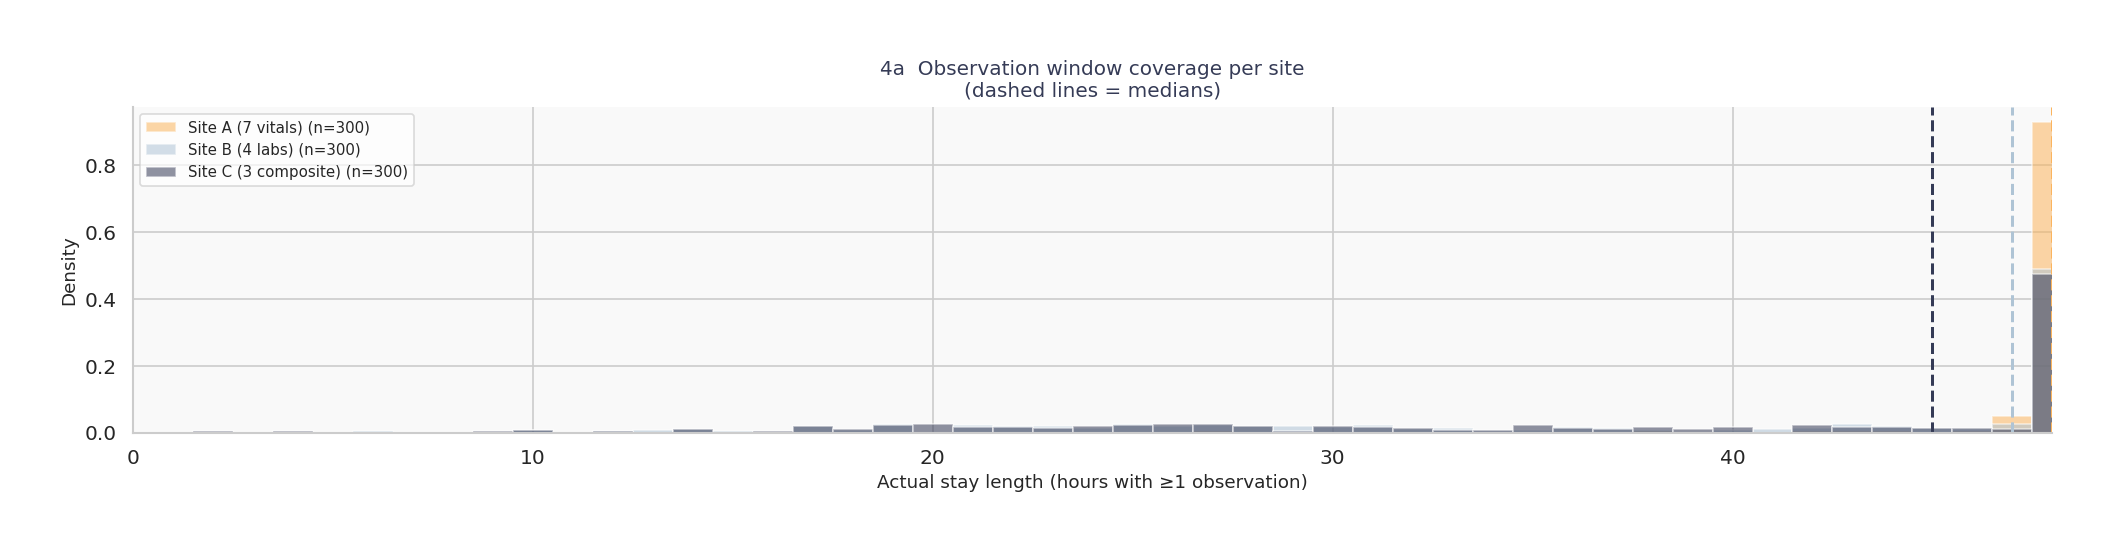

In [14]:
# ── 4a: Stay length distribution ────────────────────────────────────────────
fig_a, ax_top = plt.subplots(figsize=(17, 4))
fig_a.patch.set_facecolor('white')

bins = np.arange(0, MAX_SEQ + 2) - 0.5
for name, res in results.items():
    label = name.replace('\n', ' ')
    ax_top.hist(res['lens'], bins=bins, density=True,
                alpha=0.55, color=res['cfg']['color'],
                label=f"{label} (n={res['n']})")
    ax_top.axvline(np.median(res['lens']), color=res['cfg']['color'],
                   lw=1.8, ls='--')

ax_top.set_xlim(0, MAX_SEQ)
ax_top.set_xlabel('Actual stay length (hours with ≥1 observation)', fontsize=11)
ax_top.set_ylabel('Density', fontsize=11)
ax_top.set_title('4a  Observation window coverage per site\n'
                 '(dashed lines = medians)', fontsize=12, color='#353b56')
ax_top.legend(fontsize=9, framealpha=0.7)
ax_top.set_facecolor('#f9f9f9')
ax_top.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


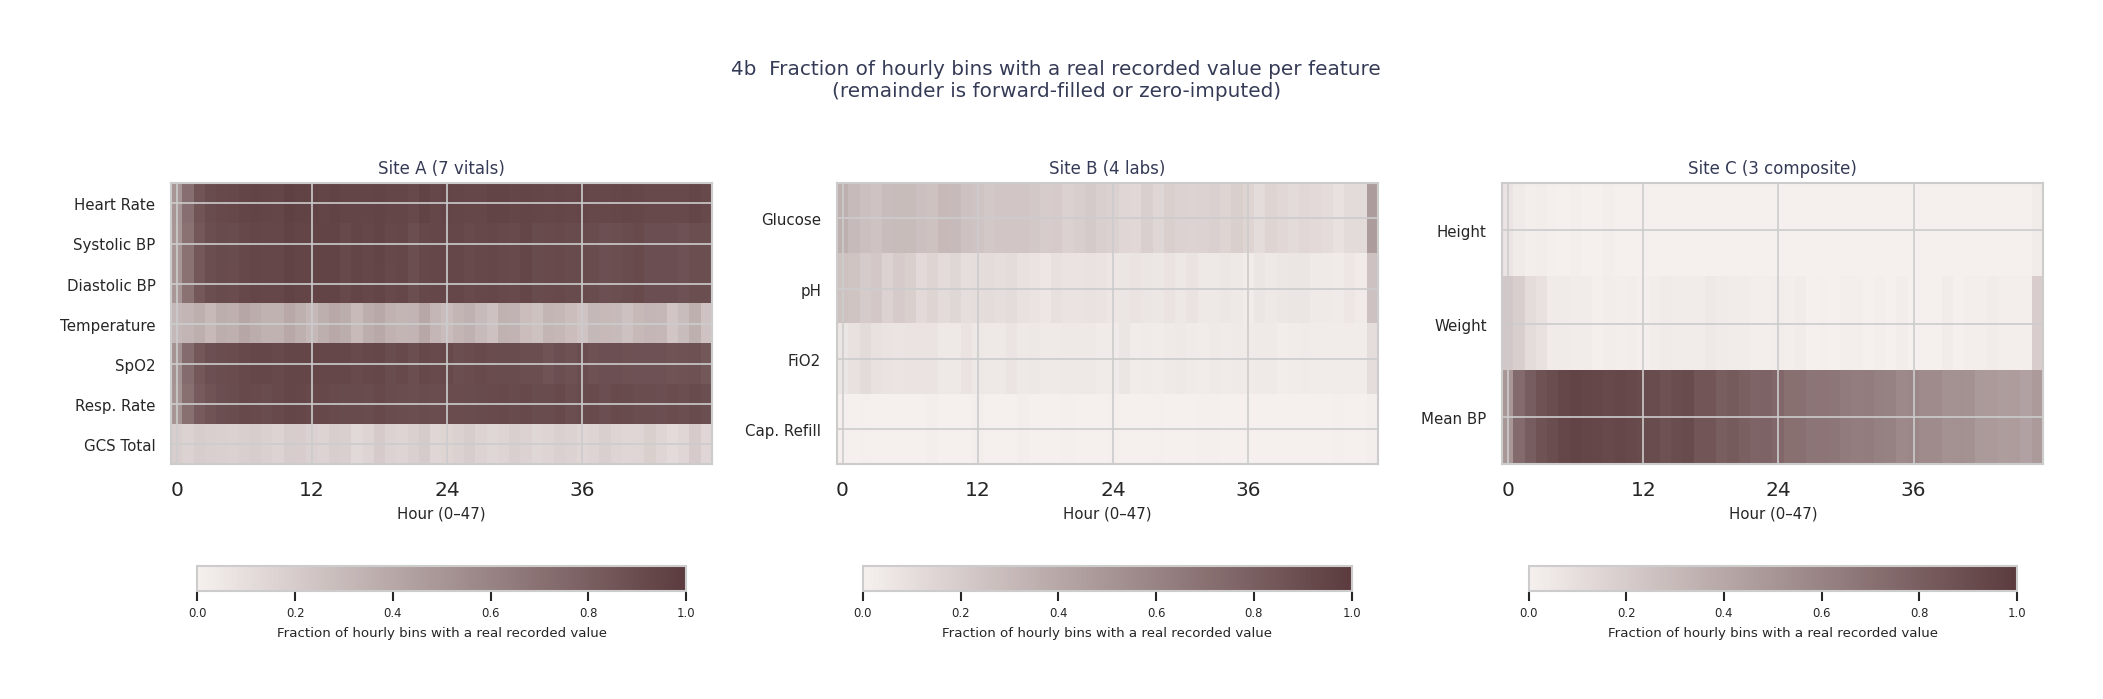

In [15]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker

DISPLAY_NAMES_ALL = {
    'Heart Rate': 'Heart Rate',
    'Systolic blood pressure': 'Systolic BP',
    'Diastolic blood pressure': 'Diastolic BP',
    'Temperature': 'Temperature',
    'Oxygen saturation': 'SpO2',
    'Respiratory rate': 'Resp. Rate',
    'Glascow coma scale total': 'GCS Total',
    'Glucose': 'Glucose',
    'pH': 'pH',
    'Fraction inspired oxygen': 'FiO2',
    'Capillary refill rate': 'Cap. Refill',
    'Height': 'Height',
    'Weight': 'Weight',
    'Mean blood pressure': 'Mean BP',
}

# ── 4b: Per-feature hourly observation rate heatmaps ────────────────────────
cmap = LinearSegmentedColormap.from_list('obs', ['#f5f0ee', '#5b3b3e'], N=256)

site_items = list(results.items())
n_sites    = len(site_items)
max_feats  = max(len(res['cfg']['features']) for _, res in site_items)

fig_b, axes_b = plt.subplots(1, n_sites, figsize=(17, max(3, max_feats * 0.7)))
fig_b.patch.set_facecolor('white')

for ax, (name, res) in zip(axes_b, site_items):
    features = res['cfg']['features']
    rate     = res['obs_rate']          # (48, n_feat)
    labels   = [DISPLAY_NAMES_ALL.get(f, f) for f in features]

    im = ax.imshow(rate.T, aspect='auto', origin='upper',
                   cmap=cmap, vmin=0, vmax=1,
                   extent=[-0.5, MAX_SEQ - 0.5, len(features) - 0.5, -0.5])

    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Hour (0–47)', fontsize=9)
    ax.set_title(name.replace('\n', ' '), fontsize=10, color='#353b56')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(12))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(6))

    cb = fig_b.colorbar(im, ax=ax, orientation='horizontal', pad=0.25, fraction=0.06)
    cb.set_label('Fraction of hourly bins with a real recorded value', fontsize=8)
    cb.ax.tick_params(labelsize=7)

fig_b.suptitle('4b  Fraction of hourly bins with a real recorded value per feature\n'
               '(remainder is forward-filled or zero-imputed)',
               fontsize=12, color='#353b56', y=1.02)
plt.tight_layout()
plt.show()


### Analysis 5: PSI Attrition

**5a — Attrition funnel**: horizontal bars showing unique patient counts for Sites B and C before and after PSI alignment. ~46% of patients are dropped; attrition is entirely driven by Site A's IHM eligibility requirement (≥48h ICU stay with a defined outcome).

**5b — LOS distribution**: grouped bars comparing the length-of-stay distribution of included vs. excluded patients (MW p=0.000). Excluded patients concentrate heavily in short stays (1–3 days), while included patients spread across longer stays. This is a direct consequence of the 48h IHM floor.

**5c — Phenotype prevalence scatter**: one point per phenotype, plotting included vs. excluded prevalence against the diagonal (no-bias line). Most points fall below the diagonal, indicating included patients have systematically higher phenotype prevalence. 

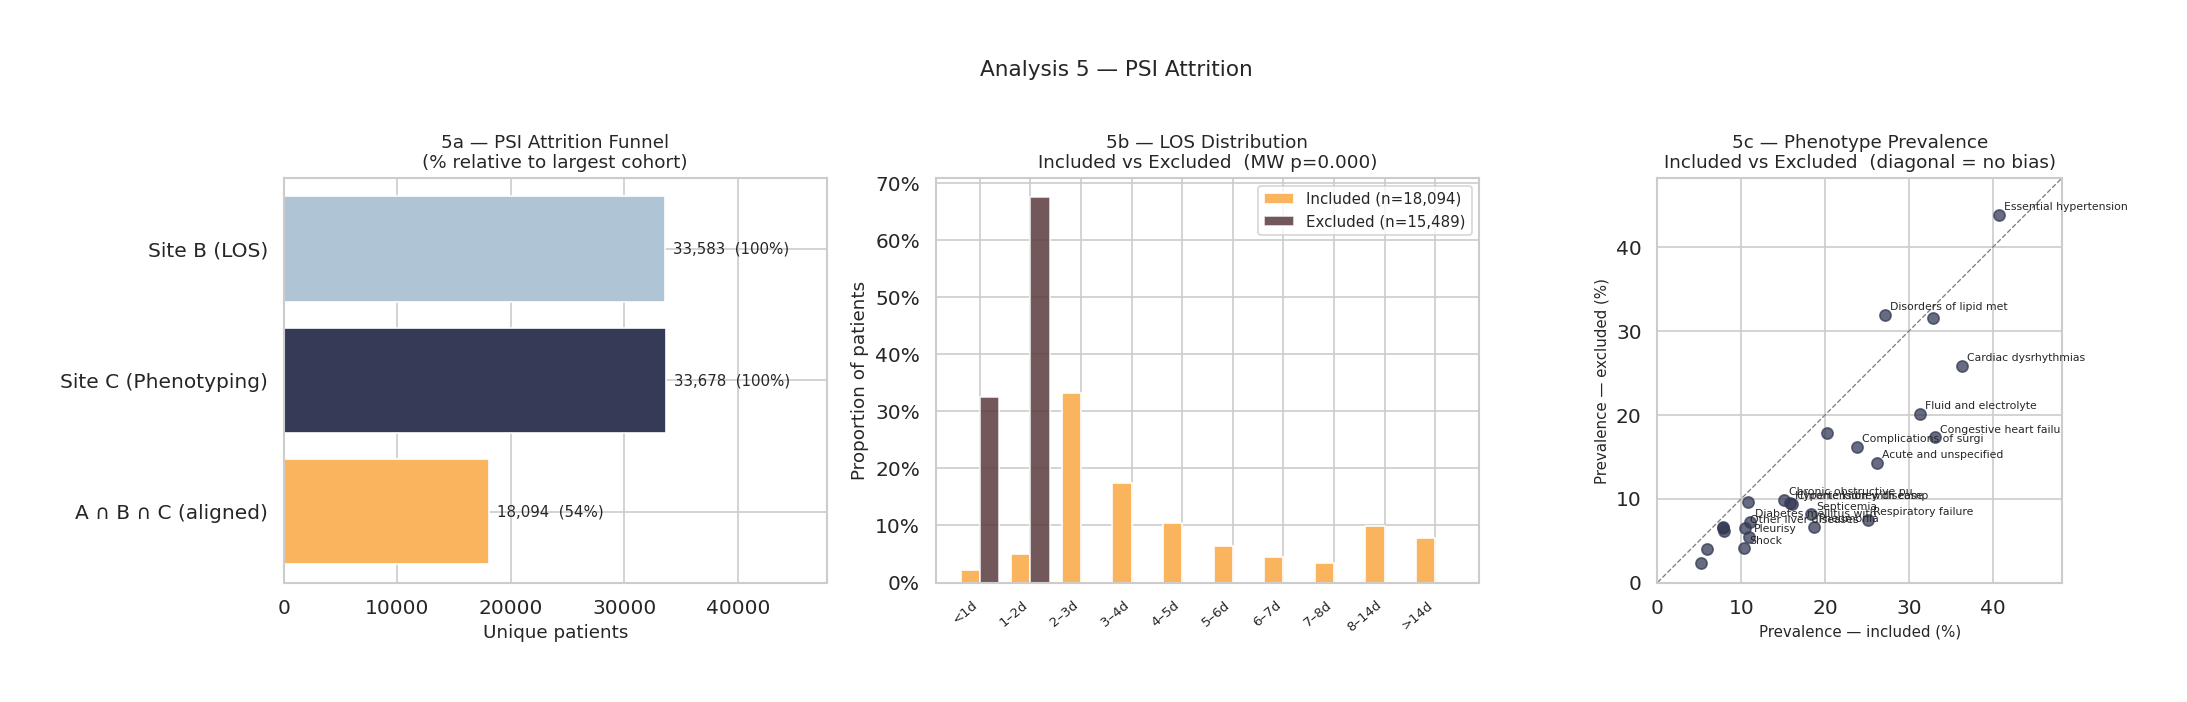

Site B (LOS):         33,583 unique patients → aligned: 18,094  (46.1% dropped)
Site C (Phenotyping): 33,678 unique patients → aligned: 18,094  (46.3% dropped)
Note: A ⊆ B and A ⊆ C — attrition is entirely driven by IHM eligibility (48h ICU window + defined outcome).

LOS median — included: 82h  |  excluded: 28h
Mann-Whitney U on LOS: stat=270908041, p=0.0000

Mean phenotype prevalence — included: 18.8%  |  excluded: 13.1%
Max prevalence gap across phenotypes: 17.6pp  (Respiratory failure; insufficiency;)


In [16]:
from scipy.stats import mannwhitneyu

# ── Patient sets ───────────────────────────────────────────────────────────
# Site A (IHM) is the most restrictive cohort
# PSI drops no IHM patients; attrition is felt entirely by Sites B and C.
subs_a = set(site_a['subject_id'].unique())   
subs_b = set(site_b['subject_id'].unique()) 
subs_c = set(site_c['subject_id'].unique())  
aligned_subs = subs_a & subs_b & subs_c    

n_a, n_b, n_c, n_abc = len(subs_a), len(subs_b), len(subs_c), len(aligned_subs)

# ── LOS: one stay per patient (first chronological stay) ──────────────────
los_first = (site_b.sort_values('stay')
                   .drop_duplicates('subject_id')
                   .set_index('subject_id')['y_los'])
los_inc = los_first[los_first.index.isin(aligned_subs)]
los_exc = los_first[~los_first.index.isin(aligned_subs)]

los_boundaries = [0, 24, 48, 72, 96, 120, 144, 168, 192, 336, np.inf]
bin_labels      = ['<1d', '1–2d', '2–3d', '3–4d', '4–5d',
                   '5–6d', '6–7d', '7–8d', '8–14d', '>14d']
inc_bins = (pd.cut(los_inc, bins=los_boundaries, labels=bin_labels, right=False)
              .value_counts().reindex(bin_labels, fill_value=0) / len(los_inc))
exc_bins = (pd.cut(los_exc, bins=los_boundaries, labels=bin_labels, right=False)
              .value_counts().reindex(bin_labels, fill_value=0) / len(los_exc))
mw_stat, mw_p = mannwhitneyu(los_inc.dropna(), los_exc.dropna(), alternative='two-sided')

# ── Phenotype prevalence ───────────────────────────────────────────────────
pheno_inc_prev = site_c[site_c['subject_id'].isin(aligned_subs)][PHENO_COLS].mean() * 100
pheno_exc_prev = site_c[~site_c['subject_id'].isin(aligned_subs)][PHENO_COLS].mean() * 100

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a — Corrected attrition funnel (Sites B/C → aligned)
ax = axes[0]
ref = max(n_b, n_c)
rows = [
    ('Site B (LOS)',        n_b,   PALETTE[4]),
    ('Site C (Phenotyping)', n_c,  PALETTE[6]),
    ('A ∩ B ∩ C (aligned)', n_abc, PALETTE[0]),
]
labels_r = [r[0] for r in rows[::-1]]
counts_r = [r[1] for r in rows[::-1]]
colors_r = [r[2] for r in rows[::-1]]
bars = ax.barh(labels_r, counts_r, color=colors_r, edgecolor='white')
for bar, v in zip(bars, counts_r):
    ax.text(bar.get_width() + ref * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{v:,}  ({100*v/ref:.0f}%)', va='center', fontsize=9)
ax.set_xlabel('Unique patients')
ax.set_xlim(0, ref * 1.42)
ax.set_title('5a — PSI Attrition Funnel\n(% relative to largest cohort)', fontsize=11)

# 5b — LOS distribution: included vs excluded
ax = axes[1]
x = np.arange(len(bin_labels))
w = 0.38
ax.bar(x - w/2, inc_bins.values, width=w, color=PALETTE[0],
       label=f'Included (n={len(los_inc):,})', edgecolor='white')
ax.bar(x + w/2, exc_bins.values, width=w, color=PALETTE[1],
       label=f'Excluded (n={len(los_exc):,})', edgecolor='white', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Proportion of patients')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title(f'5b — LOS Distribution\nIncluded vs Excluded  (MW p={mw_p:.3f})', fontsize=11)
ax.legend(fontsize=9)

# 5c — Phenotype prevalence scatter: included vs excluded
ax = axes[2]
max_prev = max(pheno_inc_prev.max(), pheno_exc_prev.max()) * 1.1
ax.scatter(pheno_inc_prev.values, pheno_exc_prev.values,
           color=PALETTE[6], alpha=0.75, s=45, zorder=3)
ax.plot([0, max_prev], [0, max_prev], color='grey', lw=0.8, ls='--', zorder=2)
abbrev_short = {c: c.split('(')[0].split(';')[0].strip()[:22] for c in PHENO_COLS}
for col, xi, yi in zip(PHENO_COLS, pheno_inc_prev.values, pheno_exc_prev.values):
    if abs(xi - yi) > 3:
        ax.annotate(abbrev_short[col], (xi, yi), fontsize=6.5,
                    xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Prevalence — included (%)', fontsize=9)
ax.set_ylabel('Prevalence — excluded (%)', fontsize=9)
ax.set_xlim(0, max_prev)
ax.set_ylim(0, max_prev)
ax.set_title('5c — Phenotype Prevalence\nIncluded vs Excluded  (diagonal = no bias)', fontsize=11)
ax.set_aspect('equal')

plt.suptitle('Analysis 5 — PSI Attrition', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print(f'Site B (LOS):         {n_b:,} unique patients → aligned: {n_abc:,}  '
      f'({100*(1 - n_abc/n_b):.1f}% dropped)')
print(f'Site C (Phenotyping): {n_c:,} unique patients → aligned: {n_abc:,}  '
      f'({100*(1 - n_abc/n_c):.1f}% dropped)')
print(f'Note: A ⊆ B and A ⊆ C — attrition is entirely driven by IHM eligibility '
      f'(48h ICU window + defined outcome).')
print(f'\nLOS median — included: {los_inc.median():.0f}h  |  excluded: {los_exc.median():.0f}h')
print(f'Mann-Whitney U on LOS: stat={mw_stat:.0f}, p={mw_p:.4f}')
print(f'\nMean phenotype prevalence — included: {pheno_inc_prev.mean():.1f}%  '
      f'|  excluded: {pheno_exc_prev.mean():.1f}%')
print(f'Max prevalence gap across phenotypes: '
      f'{(pheno_inc_prev - pheno_exc_prev).abs().max():.1f}pp  '
      f'({(pheno_inc_prev - pheno_exc_prev).abs().idxmax()[:35]})')

### Analysis 6: Cross-label Correlation

Pearson correlation between IHM, LOS, and each of the 25 phenotype labels, computed
on the PSI-aligned cohort (one stay per patient). High cross-label correlation motivates
multi-task learning: gradient signal from one task leaks useful information about others.
The IHM × LOS value is annotated explicitly as the key inter-task relationship.

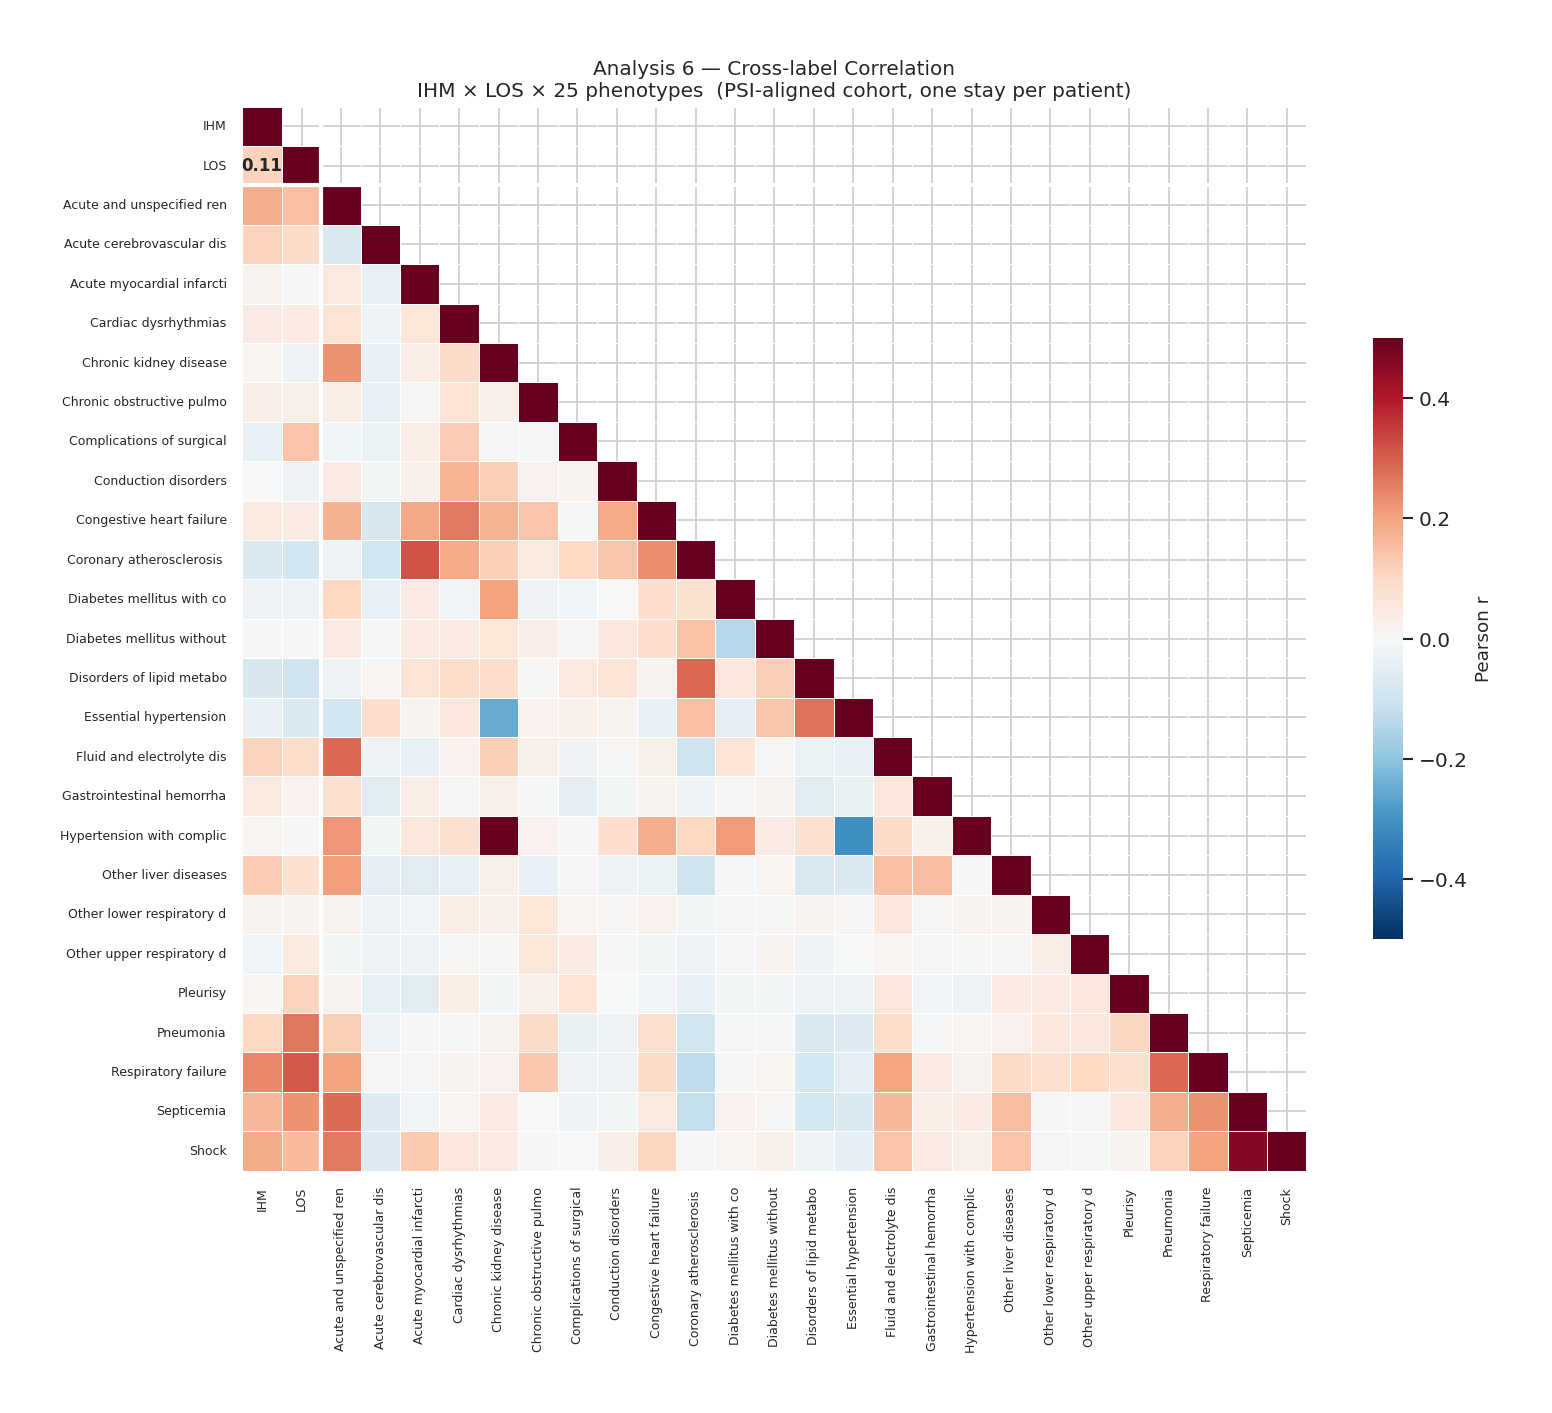

In [17]:
# One row per aligned patient (first stay per subject) to avoid repeated-patient inflation
aligned_set = set(aligned['subject_id'])

def first_stay_labels(df, cols):
    return (df[df['subject_id'].isin(aligned_set)]
            .sort_values('stay')
            .drop_duplicates('subject_id')
            .set_index('subject_id')[cols])

# Merge IHM, LOS, and phenotype labels into one table
lbl = (first_stay_labels(site_a, ['y_ihm'])
       .join(first_stay_labels(site_b, ['y_los']),  how='inner')
       .join(first_stay_labels(site_c, PHENO_COLS), how='inner'))

lbl.columns = (['IHM', 'LOS'] +
               [c.split('(')[0].split(';')[0].strip()[:25] for c in PHENO_COLS])

corr = lbl.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            linewidths=0.3, square=True, annot=False,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.55}, ax=ax)

# Annotate the IHM × LOS cell — the primary cross-task relationship
ax.text(0.5, 1.5, f'{corr.iloc[1, 0]:.2f}',
        ha='center', va='center', fontsize=10, fontweight='bold')

# White lines separating the IHM/LOS block from the 25 phenotype block
ax.axhline(2, color='white', linewidth=2.5)
ax.axvline(2, color='white', linewidth=2.5)

ax.set_title('Analysis 6 — Cross-label Correlation\n'
             'IHM × LOS × 25 phenotypes  (PSI-aligned cohort, one stay per patient)',
             fontsize=12)
ax.tick_params(axis='x', rotation=90, labelsize=7.5)
ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()
fig.savefig('figures/fig6_crosslabelcorr.svg', bbox_inches='tight', format='svg')  
plt.show()

### Analysis 7: Feature-to-task Signal

For each of the 14 features, how much signal does it carry for each of the three tasks?
Metric: |Pearson r| for IHM and phenotyping (binary targets); |Spearman r| for LOS (ordinal).
Phenotyping column shows mean |r| across all 25 labels. Computed on aligned training patients
only to prevent any val/test leakage. White lines mark site boundaries.

Off-diagonal signal (e.g. Site B features correlating with IHM) directly justifies
cross-site embedding sharing in the VFL-MTL framework.

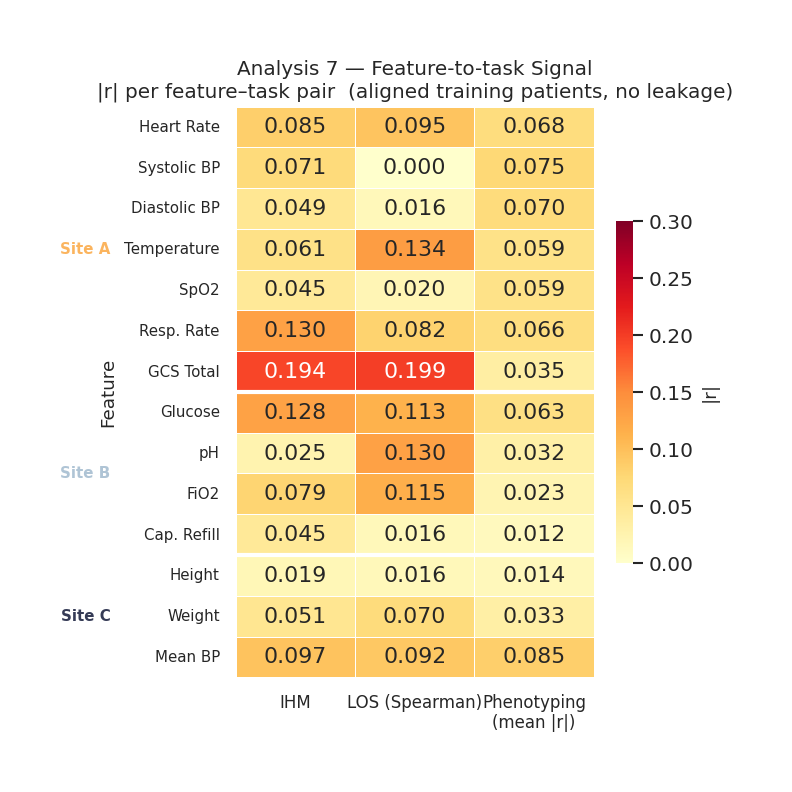

In [18]:
from scipy.stats import spearmanr

# Restrict to aligned training patients — one row per subject
train_ids = set(aligned.loc[aligned['split'] == 'train', 'subject_id'])

def train_first_stay(df, cols):
    return (df[(df['subject_id'].isin(train_ids)) & (df['split'] == 'train')]
            .drop_duplicates('subject_id')
            .set_index('subject_id')[cols])

feats   = pd.concat([train_first_stay(site_a, FEATURES_A),
                     train_first_stay(site_b, FEATURES_B),
                     train_first_stay(site_c, FEATURES_C)], axis=1)
y_ihm_s = train_first_stay(site_a, ['y_ihm'])
y_los_s = train_first_stay(site_b, ['y_los'])
y_phe_s = train_first_stay(site_c, PHENO_COLS)

# Common subjects across all five tables
common = sorted(set(feats.index) & set(y_ihm_s.index)
                & set(y_los_s.index) & set(y_phe_s.index))
feats   = feats.loc[common]
y_ihm_v = y_ihm_s.loc[common, 'y_ihm'].values
y_los_v = y_los_s.loc[common, 'y_los'].values
y_phe_v = y_phe_s.loc[common].values   # (N, 25)

all_feats = FEATURES_A + FEATURES_B + FEATURES_C
rows = []
for feat in all_feats:
    x  = feats[feat].values
    ok = ~np.isnan(x)
    r_ihm   = abs(np.corrcoef(x[ok], y_ihm_v[ok])[0, 1])
    r_los   = abs(spearmanr(x[ok], y_los_v[ok]).statistic)
    # Mean |r| across 25 phenotype labels — aggregates the multi-label signal
    r_pheno = float(np.nanmean(
        [abs(np.corrcoef(x[ok], y_phe_v[ok, j])[0, 1]) for j in range(25)]
    ))
    rows.append({'Feature': DISPLAY_NAMES_ALL.get(feat, feat),
                 'IHM': r_ihm, 'LOS (Spearman)': r_los,
                 'Phenotyping\n(mean |r|)': r_pheno})

signal = pd.DataFrame(rows).set_index('Feature')

# Site boundary positions in the heatmap row axis
cuts = [len(FEATURES_A), len(FEATURES_A) + len(FEATURES_B)]

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(signal, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=0.3, linewidths=0.5,
            cbar_kws={'label': '|r|', 'shrink': 0.6}, ax=ax)

for b in cuts:
    ax.axhline(b, color='white', linewidth=2.5)

# Site labels on the left margin
for pos, name, color in zip(
    [len(FEATURES_A)/2,
     len(FEATURES_A) + len(FEATURES_B)/2,
     len(FEATURES_A) + len(FEATURES_B) + len(FEATURES_C)/2],
    ['Site A', 'Site B', 'Site C'],
    [PALETTE[0], PALETTE[4], PALETTE[6]]
):
    ax.text(-0.35, pos, name, va='center', ha='right', fontsize=9,
            color=color, fontweight='bold', transform=ax.get_yaxis_transform())

ax.set_title('Analysis 7 — Feature-to-task Signal\n'
             '|r| per feature–task pair  (aligned training patients, no leakage)',
             fontsize=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
fig.savefig('figures/fig7_featuretotask.svg', bbox_inches='tight', format='svg')  
plt.show()